## Lecture 5: Parallel Computing 2 — Granularity, Load Balancing & Map-Filter-Reduce

### ****Exercise 1:** Overhead vs. Granularity (25 min)**

****Goal:** Observe how chunk size $L$ affects parallel overhead using Monte Carlo $\pi$.**

In [1]:
# From slide 23


from multiprocessing import Pool
import random
import time
import os


def monte_carlo_chunk(num_samples):
    """Estimate pi contributions for num_samples random points."""
    inside = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside += 1
    return inside


def test_granularity(total_work, chunk_size, n_proc):
    n_chunks = total_work // chunk_size
    tasks = [chunk_size] * n_chunks
    t0 = time.perf_counter()
    if n_proc == 1:
        results = [monte_carlo_chunk(s) for s in tasks]
    else:
        with Pool(processes=n_proc) as pool:
            results = pool.map(monte_carlo_chunk, tasks)
    return time.perf_counter() - t0, 4 * sum(results) / total_work


if __name__ == '__main__':
    total_work = 1_000_000
    n_proc = os.cpu_count() // 2
    chunk_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
    print(f"{'L':>12} | {'serial (s)':>12} | {'parallel (s)':>12}")
    for L in chunk_sizes:
        t_ser, _ = test_granularity(total_work, L, n_proc=1)
        t_par, pi = test_granularity(total_work, L, n_proc=n_proc)
        print(f"{L:12d} | {t_ser:12.4f} | {t_par:12.4f} pi={pi:.4f}")

           L |   serial (s) | parallel (s)
          10 |       0.1458 |       0.0779 pi=3.1409
         100 |       0.1270 |       0.0664 pi=3.1415
        1000 |       0.1181 |       0.0491 pi=3.1430
       10000 |       0.0869 |       0.0555 pi=3.1454
      100000 |       0.0885 |       0.0575 pi=3.1390
     1000000 |       0.0926 |       0.1268 pi=3.1429


****Setup:****

- **Total work $N$ = const (same total compute regardless of $L$)**

Done. Please see the code above. Here $N = 1,000,000$

- **Vary $L$ from $10$ to $1,000,000$ samples per chunk**

Done. Please see the code above.

- **Test with `P=1` (serial) and `P=os.cpu count()//2` (parallel)**

Done. Please see the code above.

- **Print elapsed time for each configuration**

Done. Please see the code above.

****What to look for:****

- **Serial time: stays roughly flat (computation is constant, no IPC overhead)**

I have decided to plot it.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

total_work = 1_000_000
chunk_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
n_proc = os.cpu_count() // 2

def exercise1_compute():
    times_serial = []
    times_parallel = []
    for L in chunk_sizes:
        t_ser, _ = test_granularity(total_work, L, n_proc=1)
        t_par, _ = test_granularity(total_work, L, n_proc=n_proc)
        times_serial.append(t_ser)
        times_parallel.append(t_par)
    return times_serial, times_parallel

ex1_file = Path("l05_ex1_res.npz")
if not ex1_file.exists():
    serial, parallel = exercise1_compute()
    np.savez(ex1_file, serial=serial, parallel=parallel)

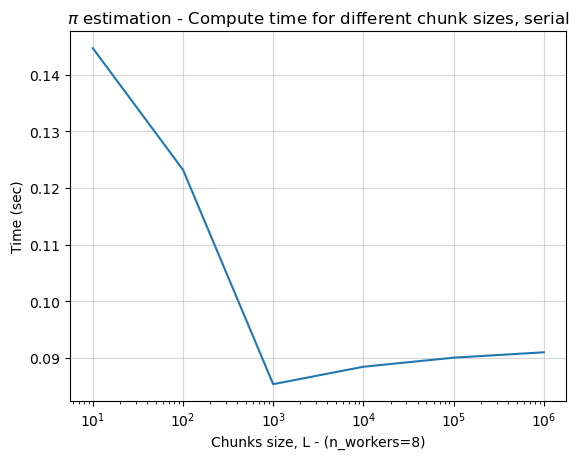

In [3]:
times_serial = np.load(ex1_file)["serial"]

plt.plot(chunk_sizes, times_serial)
plt.xlabel(f"Chunks size, L - (n_workers={n_proc})")
plt.xscale("log")
plt.ylabel("Time (sec)")
plt.grid(alpha=0.5)
plt.title(r"$\pi$ estimation - Compute time for different chunk sizes, serial")

plt.show()

The serial runtime remains relatively flat after the chunk size of $L=1000$.

- **Parallel time: U-shaped curve — high overhead at small $L$, poor balance at large $L$**

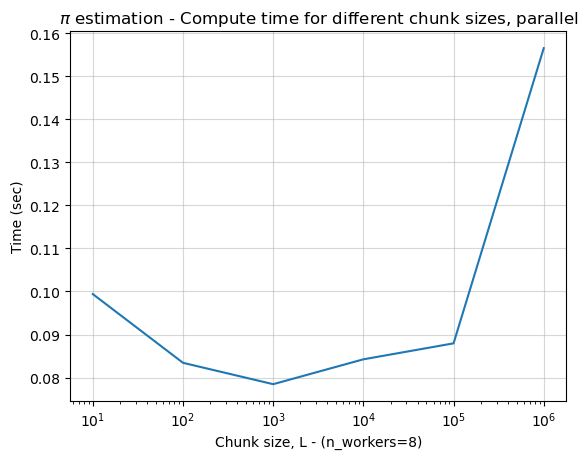

In [4]:
times_serial = np.load(ex1_file)["parallel"]

plt.plot(chunk_sizes, times_serial)
plt.xlabel(f"Chunk size, L - (n_workers={n_proc})")
plt.xscale("log")
plt.ylabel("Time (sec)")
plt.grid(alpha=0.5)
plt.title(r"$\pi$ estimation - Compute time for different chunk sizes, parallel")

plt.show()

We see a somewhat *u*-shape using the log scale.

- **Where is the optimal $L$ for your machine?**

Based on the previous plots, the most optimal chunk size on my machine is $L=1000$ for both the serial and parallel cases.

One can observe from the plot, that the left side suffers from load imbalance while the right side suffers from scheduling overhead.

****Done?** Identify optimal chunk size → discuss with a neighbour**

My peer neighbour had some weird results regarding the parallel case, likely due to how their OS (macOS) spawns new processes using Pythons `Pool`. This resulted in slowdowns compared to their serial results.

When comparing our results, we were both able to identify the optimal chunk size.

### ****Exercise 2:** Serial pipeline → parallel map**

****Data:** $N = 1,000,000$ random integers in $[10, 100]$**

****Pipeline:** map (subtract 7) → filter (keep odd) → reduce (sum)**

In [5]:
# From slide 25

# Setup — data and worker function (module-level for pickling):
import random, time
from functools import reduce
from multiprocessing import Pool

N = 1_000_000
data = [random.randint(10, 100) for _ in range(N)]

def subtract_seven(x):
    return x - 7

#### ****Part 1:** — Serial (10 min):**

In [6]:
# From slide 25

# Part 1 — serial pipeline (map / filter / reduce chained):
t0 = time.perf_counter()
result_ser = reduce(lambda a, b: a + b,
                    filter(lambda x: x % 2 == 1,
                           map(subtract_seven, data)))

t_serial = time.perf_counter() - t0

- **Implement the pipeline using `map()`, `filter()`, `reduce()` built-ins**

Done. Please see the code above.

- **Run and verify the result**

I am unsure what exactly is meant by "verify results", thus I have decided to implement my own using style 3 form slide 18.

In [7]:
result_verify = 0
for x in data:
    sv = subtract_seven(x)      # map
    if sv % 2 == 1:             # filter
        result_verify += sv     # reduce

In [8]:
assert result_verify == result_ser

print(f"Part 1 time (serial): {t_serial:.3f}s")

Part 1 time (serial): 0.113s


#### ****Part 2:** — Parallel (15 min):**

In [9]:
# From slide 25

# Part 2 — replace `map()` with `Pool.map()`:
t0 = time.perf_counter()
with Pool() as pool:
    mapped = pool.map(subtract_seven, data)
result_par = reduce(lambda a, b: a + b,
                    filter(lambda x: x % 2 == 1, mapped))
t_parallel = time.perf_counter() - t0

print(f"Serial:     {t_serial:.4f}s result={result_ser}")
print(f"Parallel:   {t_parallel:.4f}s result={result_par}")
print(f"Speedup:    {t_serial / t_parallel:.2f}x")

Serial:     0.1128s result=24204478
Parallel:   0.2708s result=24204478
Speedup:    0.42x


- ****Before running — predict:** will `Pool.map()` be faster? Why or why not?**

I predict no, since the overhead of scheduling and process creation far outweighs the cost of a simple subtraction.

- **Replace `map(subtract_seven, data)` with `pool.map(subtract_seven, data)`**

Done. Please see the code above.

- **Time both versions and compare**

In [10]:
print(f"Serial:     {t_serial:.4f}s result={result_ser}")
print(f"Parallel:   {t_parallel:.4f}s result={result_par}")
print(f"Speedup:    {t_serial / t_parallel:.2f}x")

Serial:     0.1128s result=24204478
Parallel:   0.2708s result=24204478
Speedup:    0.42x


**After running:**

- **Was your prediction correct?**

Yes.

- **How does this compare to the overhead curve you saw in E1?**

*serial*: Comparing to computing pie with just subtraction seven, the computational cost or workload needed per chunk is *much* lower, resulting in *finer-grained* tasks. Comparing with the optimal runtime from exercise 1, we see a speedup of $\frac{0.095}{0.1128}=0.84\times$ in fact a slowdown. Looking at the serial graph from exercise 1, the result from this exercise would fall on the left side of curve.

*parallel*: The parallel version also suffers from too fine-grained tasks plus the addition of scheduling overhead. Comparing with the optimal runtime from exercise 1, we see a speedup of $\frac{0.089}{0.2708}=0.33\times$ a slowdown in fact, and a much greater slowdown compared to the serial case. Looking at the parallel graph form exercise 1, the result of this exercise would fall left hand side of the curve.

****Done?** Discuss with a neighbour → move on to MP2 milestones**

Noted! I discussed it with my neighbour and they saw the same tendency in their results.

### ****Milestone 1:** Chunked Mandelbrot (20 min)**

****Goal:** Decouple the number of chunks from the number of workers.**

In [11]:
from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def _worker(args): 
    return mandelbrot_chunk(*args) # plain Python, must be module-level

In [12]:
# From slide 27

# Extend your L04 mandelbrot parallel to (include n chunks):
def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4, n_chunks=None):
    if n_chunks is None:
        n_chunks = n_workers
    chunk_size = max(1, N // n_chunks)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    tiny = [(0, 8, 8, x_min, x_max, y_min, y_max, max_iter)]
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

****What to do:****

- **Add an `n_chunks` parameter to `mandelbrot_parallel` (default: `n_chunks = n_workers`)**

Done. Please see the code above.

- **Verify output still matches the serial result from L04**

In [13]:
# This is a copy from lecture 4, but with updated function names


# From slide 45 (The updated once)

# mandelbrot_parallel.py (Tasks 1-3 are one continuous script)
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path

@njit
def mandelbrot_pixel_l04(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit
def mandelbrot_chunk_l04(row_start, row_end, N,
                     x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel_l04(x_min + col*dx, c_imag, max_iter)
    return out

def mandelbrot_serial_l04(N, x_min, x_max, y_min, y_max, max_iter=100):
    return mandelbrot_chunk_l04(0, N, N, x_min, x_max, y_min, y_max, max_iter)

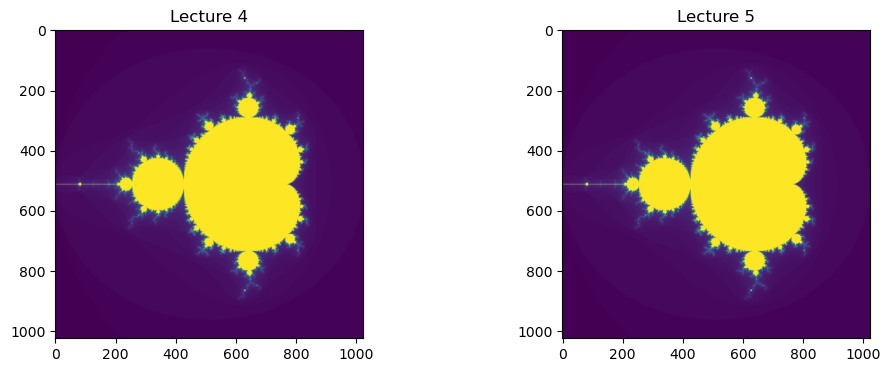

In [14]:
l04_image = mandelbrot_serial_l04(1024, -2, 1, -1.5, 1.5, 100)
l05_image = mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=os.cpu_count()//2)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(l04_image)
axes[0].set_title("Lecture 4")
axes[1].imshow(l05_image)
axes[1].set_title("Lecture 5")
plt.show()

They appear the same.

- **Re-run the L04 worker-count benchmark with `n_chunks = 4 × n_workers`; note any change**

Note that there is no `n_chunks` in lecture 4.

In [15]:
!cat l04_exercises.ipynb | grep -i "n_chunks"

I therefore assume that I am asked to compare with the benchmark from milestone 3 in lecture 4.

In [16]:
# Copy from lecture 4, milestone 3 - adaptive with new function names + n_chunks

def compute_l04(compare: bool):
    # From slide 49

    # --- MP2 M3: benchmark (in __main__ block) ---
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25

    # Serial baseline (Numba already warm after M1 warm-up)
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        mandelbrot_serial_l04(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)

    for n_workers in range(1, os.cpu_count() + 1):
        if compare:
            chunk_size = max(1, N // (4 * n_workers))
        else:
            chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter))
            row = end

        # Assert added by me
        if compare:
            n_chunks = 4 * n_workers
            # there may be more chunks needed to include trailing rows
            assert n_chunks <= len(chunks)

        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks)           # warm-up: Numba JIT in all workers
            times = []
            for _ in range(3):
                t0 = time.perf_counter()
                np.vstack(pool.map(_worker, chunks))
                times.append(time.perf_counter() - t0)
        t_par = statistics.median(times)
        speedup = t_serial / t_par
        # Added by me: include print og chunks
        print(f"{n_workers:2d} workers: {t_par:.3f}s, speedup={speedup:.2f}x, eff={speedup/n_workers*100:.0f}%, n_chunks={len(chunks)}")


In [17]:
compute_l04(False) # n_chunks ≈ n_workers (Default)

 1 workers: 0.061s, speedup=1.15x, eff=115%, n_chunks=1
 2 workers: 0.034s, speedup=2.09x, eff=105%, n_chunks=2
 3 workers: 0.036s, speedup=1.93x, eff=64%, n_chunks=4
 4 workers: 0.030s, speedup=2.36x, eff=59%, n_chunks=4
 5 workers: 0.027s, speedup=2.57x, eff=51%, n_chunks=6
 6 workers: 0.021s, speedup=3.31x, eff=55%, n_chunks=7
 7 workers: 0.022s, speedup=3.24x, eff=46%, n_chunks=8
 8 workers: 0.018s, speedup=3.95x, eff=49%, n_chunks=8
 9 workers: 0.016s, speedup=4.29x, eff=48%, n_chunks=10
10 workers: 0.016s, speedup=4.48x, eff=45%, n_chunks=11
11 workers: 0.014s, speedup=4.87x, eff=44%, n_chunks=12
12 workers: 0.014s, speedup=5.15x, eff=43%, n_chunks=13
13 workers: 0.012s, speedup=5.73x, eff=44%, n_chunks=14
14 workers: 0.013s, speedup=5.59x, eff=40%, n_chunks=15
15 workers: 0.014s, speedup=4.98x, eff=33%, n_chunks=16
16 workers: 0.013s, speedup=5.44x, eff=34%, n_chunks=16


In [18]:
compute_l04(True) # n_chunks ≈ 4 * n_workers

 1 workers: 0.059s, speedup=1.18x, eff=118%, n_chunks=4
 2 workers: 0.031s, speedup=2.21x, eff=111%, n_chunks=8
 3 workers: 0.023s, speedup=3.03x, eff=101%, n_chunks=13
 4 workers: 0.019s, speedup=3.57x, eff=89%, n_chunks=16
 5 workers: 0.017s, speedup=4.07x, eff=81%, n_chunks=21
 6 workers: 0.016s, speedup=4.43x, eff=74%, n_chunks=25
 7 workers: 0.013s, speedup=5.16x, eff=74%, n_chunks=29
 8 workers: 0.014s, speedup=5.12x, eff=64%, n_chunks=32
 9 workers: 0.014s, speedup=4.92x, eff=55%, n_chunks=37
10 workers: 0.013s, speedup=5.50x, eff=55%, n_chunks=41
11 workers: 0.011s, speedup=6.09x, eff=55%, n_chunks=45
12 workers: 0.013s, speedup=5.33x, eff=44%, n_chunks=49
13 workers: 0.011s, speedup=6.36x, eff=49%, n_chunks=54
14 workers: 0.011s, speedup=6.17x, eff=44%, n_chunks=57
15 workers: 0.012s, speedup=5.56x, eff=37%, n_chunks=61
16 workers: 0.012s, speedup=5.92x, eff=37%, n_chunks=64


I terms of runtime, there is effectively no differences. In theory, one would expect the runtime to increase due to extra scheduling overhead.

****Done?** Verify result matches serial output → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit d7bcbf791bc6e55289bf48742a4eedc920caa430 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 16:42:25 2026 +0000

    l05: milestone 1 done
```

### ****Milestone 2:** Optimal Chunk Size (15 min)**

****Fix `n_workers` at your L04 optimum. Sweep `n_chunks`, measure wall time, and compute LIF = $ p \cdot T_p/T_1 − 1 $.****

****Suggested configurations (`n_workers` = your best):****

| **n_chunks** | **time (s)** | **vs. 1×** | **LIF** |
| -------------- | ------------ | ---------- | ------- |
| 1× n_workers   | —            | baseline   | —       |
| 2× n_workers   | —            | —          | —       |
| 4× n_workers   | —            | —          | —       |
| 8× n_workers   | —            | —          | —       |
| 16× n_workers  | —            | —          | —       |

****Tips:****

- **Use `statistics.median()` of 3+ runs**

- **Include warm-up before timing**

- **LIF minimum = sweet spot**

- **Typical sweet spot: 4–8× `n_workers`**

I am unsure what "optimum" is. I assume that it refers to speedup.

Looking at my own lecture 4 milestone 3, the highest speedup was achieved using `n_workers=16`

*NOTE:* That the denominator in the LIF formula can be either $\sum{t_i}$ (sum of all chunk runtimes) or $T_1$ (measured serial wall time). Since we are given the formula in this exercise with $T_1$ I have chosen to use that. 

In [19]:
import statistics


def compute_mp2():
    n_workers = 16
    n_chunks = [2**i * n_workers for i in range(5)]

    all_times = []
    speedups = []
    lifs = []

    # warmup
    mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers, 16)

    for chunk in n_chunks:
        times = []
        for _ in range(3):
            # Using this lectures (l05) parallel mandelbrot
            t0 = time.perf_counter()
            mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers, chunk)
            times.append(time.perf_counter() - t0)
            
        t_par = statistics.median(times)
        all_times.append(t_par)
        speedups.append(all_times[0]/t_par)
        lifs.append(n_workers * t_par / all_times[0] - 1)
    
    return n_chunks, all_times, speedups, lifs

In [20]:
from pathlib import Path
import pandas as pd

m2_file = Path("l05_milestone2.csv")

if not m2_file.exists():
    n_chunks, times, speedups, lifs = compute_mp2()
    df = pd.DataFrame({
        "n_chunks": n_chunks,
        "time": times,
        "speedup": speedups,
        "lif": lifs
    })
    df.to_csv(m2_file, index_label=False)

Print the table using both pandas and markdown for pdf.

In [21]:
m2_results = pd.read_csv(m2_file)

display(
    m2_results.style
    .hide(axis="index")
    .format({
            "time": "{:.3f}s",
            "speedup": "{:.2f}x",
            "lif": "{:.2f}"
            })
)

n_chunks,time,speedup,lif
16,0.238s,1.00x,15.00
32,0.243s,0.98x,15.33
64,0.240s,0.99x,15.13
128,0.237s,1.01x,14.91
256,0.238s,1.00x,15.00


In [22]:
from IPython.display import Markdown, display
import pandas as pd

m2_results = pd.read_csv(m2_file)

df_display = m2_results.copy()
df_display["n_chunks"] = df_display["n_chunks"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)
df_display["lif"] = df_display["lif"].map("{:>.2f}".format)

display(Markdown(df_display.to_markdown(index=False)))

|   n_chunks | time   | speedup   |   lif |
|-----------:|:-------|:----------|------:|
|         16 | 0.238s | 1.00x     | 15    |
|         32 | 0.243s | 0.98x     | 15.33 |
|         64 | 0.240s | 0.99x     | 15.13 |
|        128 | 0.237s | 1.01x     | 14.91 |
|        256 | 0.238s | 1.00x     | 15    |

****Done?** Record optimal `n_chunks` and LIF in performance notebook (MP2) → commit**

In [23]:
m2_results = pd.read_csv(m2_file)

# Find the "sweet spot"
row_idx = m2_results["lif"].idxmin()
optimal_n_chunks = m2_results.iloc[row_idx]["n_chunks"]
optimal_lif = m2_results.iloc[row_idx]["lif"]

print(f"Optimal Number of chunks: {optimal_n_chunks:.0f}")
print(f"Optimal LIF: {optimal_lif:.2f}") # "sweet spot"

Optimal Number of chunks: 128
Optimal LIF: 14.91


```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit e5a9bc6e7feb7409accc19e2fbe290a13ffd1b84 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 18:25:46 2026 +0000

    l05: milestone 2 done
```

### ****Milestone 3:** Comprehensive Analysis (20 min)**

****Create a full performance comparison at $1024×1024$, `max_iter=100`:****

#### ****1 Speedup table:****

| **Implementation** | **Time (s)** | **Speedup** |
| ------------------ | ------------ | ----------- |
| Naive Python       | —            | 1x          |
| Numpy              | —            | —           |
| Numba (@njit)      | —            | —           |
| Parallel (opt.)    | —            | —           |

#### ****2. Speedup vs. core count:****

- **Actual vs. ideal (linear)**
- **Back-solve implied $s = \frac{1/S_p^∗ − 1/p^*}{1 − 1/p^*}$**
- **Is your s smaller than your L04 result?** - Better load balance ⇒ lower apparent $s$?

#### ****3. Brief recommendation:****

- **What settings give the best time?**

- **Is parallelisation worth it on your hardware?** - Compare speedup and LIF to your serial
Numba baseline

- **Write 2–3 sentences in your performance notebook**

#### ****4. Submit to Performance Tracker:****

- **Enter your best multiprocessing time on Moodle - (1024×1024, Implementation: “Multiprocessing”)**

****Done?** Record all results in performance notebook (MP2) → commit**